# LINCS v4

### Data Portal

[Link](https://lincsportal.ccs.miami.edu/datasets/)

### LINCS Phase 1

[LDS-1481](https://lincsportal.ccs.miami.edu/datasets/view/LDS-1191)
- Level 5 data
- 22,891 small molecules
[Gene info](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE92742)


### LINCS Phase 2

[LDS-1611](https://lincsportal.ccs.miami.edu/datasets/view/LDS-1611)
- Level 5 data
- 51,050 small molecules
- [Gene info](https://clue.io/data/CMap2020#LINCS2020)
- Perturbagen info can either be sourced from the gene info link above, or from the `Metadata` tab of the data link
- Citation:
> Todd Golub, Aravind Subramanian: L1000 Dataset - small molecule, nucleic acid perturbagens - LINCS Phase 2 (December 2021), 2021, LINCS (dataset), http://identifiers.org/lincs.data/LDS-1613, ; retrieved: Apr 23, 2025.

### Analysing Drug Signatures

[Tutorial](https://lincsproject.org/LINCS/tools/workflows/analyze-a-drug-signature-and-find-other-drugs-with-similar-signatures)

# Packages

In [136]:
from cmapPy.pandasGEXpress import parse
import inspect
import itertools
import os
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd
import pickle
import random
import re
import seaborn as sns
import umap
import warnings
from tqdm import tqdm

# Directories

In [34]:
DATA_IN = 'D:/DDesktop/_code/canada/lincs_analysis/data/input/'
DATA_OUT = 'D:/DDesktop/_code/canada/lincs_analysis/data/output/'
GRAPH_BASE = 'D:/DDesktop/_code/canada/lincs_analysis/graphs/base/'
GRAPH_CONTEXT = 'D:/DDesktop/_code/canada/lincs_analysis/graphs/context/'

# Files

## STRING

String file info/links here

In [3]:
STRING_EDGES = DATA_IN + '9606.protein.physical.links.full.v12.0.txt.gz'
STRING_INFO = DATA_IN + '9606.protein.info.v12.0.txt.gz'

## LINCS

LINCS file info/links here

In [4]:
LINCS_DATA = DATA_IN + 'LDS-1481_1.0.gctx'
LINCS_INFO = DATA_IN + 'GSE92742_Broad_LINCS_sig_info.txt'
LINCS_GENES = DATA_IN + 'GSE92742_Broad_LINCS_gene_info.txt'

# Functions

In [112]:
def func_param_typecheck(function, *args, **kwargs) -> None:
    '''
    Checks the types of parameters for a given function based on parameter annotations.

    ### Parameters

    `function`: Any

    - The function whose parameters are being checked.

    `*args`: tuple

    - Tuple of positional parameters for given function, can be any type.

    `**kwargs` : dict

    - Dictionary of keyword arguments passed to the given function, where keys are strings and values are any type.

    ### Raises

    `TypeError`

    - Error raised if any parameter does not match its annotated type
    '''

    ## FUNCTION

    # Get function signature
    function_signature = inspect.signature(function)
    # Get function arguments
    function_arguments = function_signature.bind(*args, **kwargs)

    # Iterate through function parameters and input data types
    for parameter_name, parameter_type in function_arguments.arguments.items():
        # Get expected parameter type from annotation
        expected_type = function_signature.parameters[parameter_name].annotation
        # Check the expected type isn't empty
        if expected_type != inspect.Parameter.empty:
            # Check if parameter annotations are in a Union
            if hasattr(expected_type, '__origin__') and expected_type.__origin__ is Union:
                # Type check
                if not isinstance(parameter_type, get_args(expected_type)):
                    # Extract list of allowed types
                    allowed_types = ', '.join(etype.__name__ for etype in get_args(expected_type))
                    # Raise error
                    raise TypeError(f'Parameter \'{parameter_name}\' must be one of types: \'{allowed_types}\', ' 
                                    f'but got \'{type(parameter_type).__name__}\'')
            # Else type check single annotated type
            elif not isinstance(parameter_type, expected_type):
                # Raise error
                raise TypeError(f'Parameter \'{parameter_name}\' must be of type \'{expected_type.__name__}\', '
                                f'but got \'{type(parameter_type).__name__}\'')

def graph_save(graph: nx.Graph, graph_name: str, path: str = os.getcwd(), graphml: bool = False, report: bool = False) -> None:
    '''
    Saves a NetworkX graph object to specified location using the pickle package OR as a .gml file for downstream analysis.

    ### Parameters

    `graph`: nx.Graph

    > NetworkX graph object to be saved.

    `graph_name`: str

    > Name for saved file.

    `path`: str (default = current working directory)

    > Save location.

    ### Returns

    Pickled graph object
    '''

    ## CHECK

    # Type
    func_param_typecheck(graph_save, graph, graph_name, path, graphml, report)

    ## FUNCTION

    # Check graphml parameter
    if graphml == False:
        # Pickle graph
        with open(f'{path}/{graph_name}.pkl', 'wb') as f:
            pickle.dump(graph, f)
    else:
        # Save graph as .gml file
        nx.write_graphml(graph, path = f'{path}/{graph_name}.gml')

    ## REPORT

    if report == True:
        # Statistics
        num_nodes = len(graph.nodes)
        num_edges = len(graph.edges)
        # Print
        print('>> graph_save')
        if graphml == False:
            print(f'NetworkX graph object w/ {num_nodes:,} nodes and {num_edges:,} edges saved to {path}/{graph_name}.pkl')
        else:
            print(f'NetworkX graph object w/ {num_nodes:,} nodes and {num_edges:,} edges saved to {path}/{graph_name}.gml')
        print()

def graph_load(path: str, graphml: bool = False, report: bool = False) -> nx.Graph:
    '''
    Loads a pickled NetworkX graph object.

    ### Parameters

    `path`: str

    > Location of the pickled graph file.

    ### Returns

    `graph`: nx.Graph

    > NetworkX graph object.
    '''

    ## CHECK

    # Type
    func_param_typecheck(graph_load, path, graphml, report)

    ## FUNCTION

    # Check graphml parameter
    if graphml == False:
        with open(f'{path}', 'rb') as f:
            graph = pickle.load(f)
    else:
        graph = nx.read_graphml(path)
        graph = nx.relabel_nodes(graph, lambda x: int(x))

    ## REPORT

    if report == True:
        # Statistics
        num_nodes = graph.number_of_nodes()
        num_edges = graph.number_of_edges()
        # Print
        print('>> graph_load')
        if graphml == False:
            print(f'Pickled NetworkX graph object with {num_nodes:,} nodes and {num_edges:,} edges loaded from {path}')
        else:
            print(f'GraphML NetworkX graph object with {num_nodes:,} nodes and {num_edges:,} edges loaded from {path}')
        print()

    return graph

def umap_normalise_row(row):
    '''
    Takes a dataframe row and normalises all values between -1 and 1
    '''

    max_pos = row[row > 0].max() if any(row > 0) else 1
    max_neg = row[row < 0].min() if any(row < 0) else -1

    return row.apply(lambda x:x / max_pos if x > 0 else (x / abs(max_neg) if x < 0 else 0))

def umap_normalise_df(dataframe: pd.DataFrame) -> pd.DataFrame:
    '''
    Takes a dataframe and normalises row values between -1 and 1, to prepare for uMAP dimensionality reduction
    '''

    # Apply row normalisation
    df = dataframe.apply(umap_normalise_row, axis = 1)

    return df


# STRING

This section generates the base NetworkX graph object from STRINGdb human PPI data

## Edges

In [ ]:
# Load data
string_edges = pd.read_csv(STRING_EDGES, compression = 'gzip', sep = ' ')
# Show data
string_edges.head()

,protein1,protein2,homology,experiments,experiments_transferred,database,database_transferred,textmining,textmining_transferred,combined_score
0,9606.ENSP00000000233,9606.ENSP00000257770,0,312,0,0,0,0,0,311
1,9606.ENSP00000000233,9606.ENSP00000226004,0,162,0,0,0,0,0,161
2,9606.ENSP00000000233,9606.ENSP00000434442,0,0,0,500,0,0,0,499
3,9606.ENSP00000000233,9606.ENSP00000262455,0,531,0,0,0,0,0,531
4,9606.ENSP00000000233,9606.ENSP00000303145,0,0,0,500,0,0,0,499


## Info

In [7]:
# Load data
string_info = pd.read_csv(STRING_INFO, compression = 'gzip', sep = '\t')
# Show data
string_info.head()

,#string_protein_id,preferred_name,protein_size,annotation
0,9606.ENSP00000000233,ARF5,180,ADP-ribosylation factor 5; GTP-binding protein...
1,9606.ENSP00000000412,M6PR,277,Cation-dependent mannose-6-phosphate receptor;...
2,9606.ENSP00000001008,FKBP4,459,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
3,9606.ENSP00000001146,CYP26B1,512,Cytochrome P450 26B1; Involved in the metaboli...
4,9606.ENSP00000002125,NDUFAF7,441,"Protein arginine methyltransferase NDUFAF7, mi..."


## `df_string`

In [8]:
# Define variables
source_protein_column = 'protein1'
target_protein_column = 'protein2'
score_column = 'combined_score'
protein_id_column = '#string_protein_id'
taxon_id = '9606.'

In [ ]:
# Copy edgelist
df_string = string_edges.copy(deep = True)
# Isolate columns
df_string = df_string[[source_protein_column, target_protein_column, score_column]]

# Rename string_info column
string_info.rename(columns = {protein_id_column : source_protein_column}, inplace = True)
# Merge dataframes
df_string = pd.merge(df_string, string_info[[source_protein_column, 'preferred_name', 'annotation']], how = 'left', on = source_protein_column)
# Rename string_info column
string_info.rename(columns = {source_protein_column : target_protein_column}, inplace = True)
# Merge dataframes
df_string = pd.merge(df_string, string_info[[target_protein_column, 'preferred_name', 'annotation']], how = 'left', on = target_protein_column)
# Reset string_info columns
string_info.rename(columns = {target_protein_column : protein_id_column}, inplace = True)

# Rename df_string columns
old_column_names = df_string.columns
new_column_names = ['source_id', 'target_id', 'weight', 'source', 'source_annot', 'target', 'target_annot']

for old_name, new_name in zip(old_column_names, new_column_names):
    df_string.rename(columns = {old_name : new_name}, inplace = True)

# Remove taxon ID
for column in ['source_id', 'target_id']:
    df_string[column] = df_string[column].str.replace(taxon_id, '')

# Set column order
column_order = ['source', 'target', 'weight', 'source_id', 'target_id', 'source_annot', 'target_annot']
df_string = df_string[column_order]

# Save data
df_string.to_csv(DATA_OUT + 'df_string.csv', index = False)

# Show data
df_string.head()

,source,target,weight,source_id,target_id,source_annot,target_annot
0,ARF5,NT5E,311,ENSP00000000233,ENSP00000257770,ADP-ribosylation factor 5; GTP-binding protein...,5'-nucleotidase; Hydrolyzes extracellular nucl...
1,ARF5,DUSP3,161,ENSP00000000233,ENSP00000226004,ADP-ribosylation factor 5; GTP-binding protein...,Dual specificity protein phosphatase 3; Shows ...
2,ARF5,ARFGAP2,499,ENSP00000000233,ENSP00000434442,ADP-ribosylation factor 5; GTP-binding protein...,ADP-ribosylation factor GTPase-activating prot...
3,ARF5,ERP44,531,ENSP00000000233,ENSP00000262455,ADP-ribosylation factor 5; GTP-binding protein...,Endoplasmic reticulum resident protein 44; Med...
4,ARF5,TMED10,499,ENSP00000000233,ENSP00000303145,ADP-ribosylation factor 5; GTP-binding protein...,Transmembrane emp24 domain-containing protein ...


## Base Graph

In [32]:
# Define confidence score filter
score_filter = 0

In [33]:
# Load data
df_string = pd.read_csv(DATA_OUT + 'df_string.csv')
# Generate graph object
graph_base = nx.from_pandas_edgelist(df_string[df_string.columns[0:3]], source = 'source', target = 'target', edge_attr = 'weight')
# Records number of nodes and edges
num_nodes = len(graph_base.nodes)
num_edges = len(graph_base.edges)
# Filter by edge weights
graph_base.remove_edges_from([(source, target) for source, target, weight in graph_base.edges(data = 'weight') if weight < score_filter])
# Remove unconnected nodes
graph_base.remove_nodes_from(list(nx.isolates(graph_base)))

# Record altered node/edge number
num_nodes_filter = len(graph_base.nodes)
num_edges_filter = len(graph_base.edges)
# Calculate variables
percent_nodes = num_nodes_filter / num_nodes * 100
percent_edges = num_edges_filter / num_edges * 100

# Report
print(f'Base graph of {num_nodes:,} nodes and {num_edges:,} edges generated')
print(f'Filtered for edges with a confidence score >= {score_filter}')
print(f'{percent_nodes:.2f}% nodes ({num_nodes_filter:,}/{num_nodes:,}) and {percent_edges:.2f}% edges ({num_edges_filter:,}/{num_edges:,}) remain')
print()

# Save graph
graph_save(graph_base, graph_name = 'graph_base', path = GRAPH_BASE, graphml = False, report = True)

Base graph of 18,767 nodes and 738,805 edges generated
Filtered for edges with a confidence score >= 0
100.00% nodes (18,767/18,767) and 100.00% edges (738,805/738,805) remain

>> graph_save
NetworkX graph object w/ 18,767 nodes and 738,805 edges saved to D:/DDesktop/_code/canada/lincs_analysis/graphs/base//graph_base.pkl



## Node Mapping

In [ ]:
# # Extract unique node labels
# graph_nodes_unique = sorted(graph_base.nodes())
# # Generate node map
# graph_nodes_map = {node : i for i, node in enumerate(graph_nodes_unique)}

# LINCS

- Parse data file
- Filter data file
- Generate mapping files for perturbagen/gene IDs/names
- Generate umap files for:
    - 6h and 24h data comparison
    - Sum'd 6h and 24h values per drug
    - Averaged 6h and 24h values per drug

## Info

### `df_lincs_info`

In [12]:
warnings.filterwarnings('ignore')

# Load lincs_info
df_lincs_info = pd.read_csv(LINCS_INFO, sep = '\t')
# Rename columns
df_lincs_info.rename(columns = {'pert_id' : 'perturbagen_id', 'pert_iname' : 'perturbagen_name'}, inplace = True)
# Save data
df_lincs_info.to_csv(DATA_OUT + 'df_lincs_info.csv', index = False)
# Show data
df_lincs_info.head()

,sig_id,perturbagen_id,perturbagen_name,pert_type,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id
0,AML001_CD34_24H:A05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:A05
1,AML001_CD34_24H:A06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:A06
2,AML001_CD34_24H:B05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:B05|AML001_CD34_24H_X...
3,AML001_CD34_24H:B06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:B06
4,AML001_CD34_24H:BRD-A03772856:0.37037,BRD-A03772856,BRD-A03772856,trt_cp,CD34,0.37037,µM,500 nM,24,h,24 h,AML001_CD34_24H_X1_F1B10:J04|AML001_CD34_24H_X...


### `df_lincs_perturbagens`

In [13]:
# Isolate columns
df_lincs_perturbagens = df_lincs_info[['perturbagen_id', 'perturbagen_name']]
# Remove duplicates
df_lincs_perturbagens.drop_duplicates(inplace = True, ignore_index = True)
# Generate mapping dictionary for later use
lincs_perturbagens_map = dict(zip(df_lincs_info['perturbagen_id'], df_lincs_info['perturbagen_name']))
# Save data
df_lincs_perturbagens.to_csv(DATA_OUT + 'df_lincs_perturbagens.csv', index = False)
# Show data
df_lincs_perturbagens.head()

,perturbagen_id,perturbagen_name
0,DMSO,DMSO
1,BRD-A03772856,BRD-A03772856
2,BRD-A19037878,trichostatin-a
3,BRD-A19500257,geldanamycin
4,BRD-A34037822,KUC107191N


## Gene Info

### `df_lincs_genes`

In [14]:
# Load gene info data
df_lincs_genes = pd.read_csv(LINCS_GENES, sep = '\t')
# Rename columns
df_lincs_genes.rename(columns = {'pr_gene_id' : 'rid', 'pr_gene_symbol' : 'gene_name', 'pr_gene_title' : 'gene_desc'}, inplace = True)
# Save data
df_lincs_genes.to_csv(DATA_OUT + 'df_lincs_genes.csv', index = False)
# Show data
df_lincs_genes.head()

,rid,gene_name,gene_desc,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


## Filter

In [15]:
# Define filters
lincs_filter_cells = ['HT29']
lincs_filter_timepoints = [6, 24]
lincs_filter_doses = [10]

### `df_lincs_filter`

In [ ]:
# Initialise dataframe
df_lincs_filter = df_lincs_info[(df_lincs_info['cell_id'].isin(lincs_filter_cells)) &
                                (df_lincs_info['pert_time'].isin(lincs_filter_timepoints)) &
                                (df_lincs_info['pert_dose'].isin(lincs_filter_doses))]

# Extract `sig_id` column as a list
list_sig_ids = df_lincs_filter['sig_id'].tolist()

# Report filtering criteria
print(f'Cell line(s): {lincs_filter_cells}')
print(f'Timepoint(s): {lincs_filter_timepoints}')
print(f'Dose(s): {lincs_filter_doses}')
# Report number of signature IDs
print(f'{len(list_sig_ids):,} signature IDs found meeting the desired criteria')

# Show data
df_lincs_filter.head()

Cell line(s): ['HT29']
Timepoint(s): [6, 24]
Dose(s): [10]
7,102 signature IDs found meeting the desired criteria


,sig_id,perturbagen_id,perturbagen_name,pert_type,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id
50538,CPC004_HT29_6H:BRD-A00546892-001-01-8:10,BRD-A00546892,biperiden,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:J19|CPC004_HT...
50539,CPC004_HT29_6H:BRD-A00993607-003-15-4:10,BRD-A00993607,alprenolol,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:E24|CPC004_HT...
50540,CPC004_HT29_6H:BRD-A01593789-001-02-3:10,BRD-A01593789,chlormadinone-acetate,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:H21|CPC004_HT...
50541,CPC004_HT29_6H:BRD-A01643550-001-03-1:10,BRD-A01643550,prednisolone-acetate,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:P13|CPC004_HT...
50542,CPC004_HT29_6H:BRD-A02006392-001-09-9:10,BRD-A02006392,nitrendipine,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:F14|CPC004_HT...


## Data

### `df_lincs`

In [24]:
# Filter lincs data for signature IDs
df_lincs = parse.parse(LINCS_DATA, cid = list_sig_ids).data_df
# Show data
df_lincs.head()

cid,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005_HT29_6H:BRD-A07824748-001-02-6:10,CPC004_HT29_6H:BRD-K20482099-001-01-1:10,CPC005_HT29_6H:BRD-K62929068-001-03-3:10,CPC005_HT29_6H:BRD-K43405658-001-01-8:10,CPC004_HT29_6H:BRD-K03670461-001-02-0:10,CPC004_HT29_6H:BRD-K36737713-001-01-6:10,CPC005_HT29_6H:BRD-K51223576-001-01-3:10,CPC004_HT29_6H:BRD-A14966924-001-03-0:10,CPC004_HT29_6H:BRD-K79131256-001-08-8:10,...,PCLB003_HT29_24H:BRD-K64024097-001-02-8:10,PCLB003_HT29_24H:BRD-K64106162-001-02-3:10,PCLB003_HT29_24H:BRD-K16956545-001-01-0:10,PCLB003_HT29_24H:BRD-K78431006-001-05-2:10,PCLB003_HT29_24H:BRD-K63828191-003-23-0:10,PCLB003_HT29_24H:BRD-K93754473-001-17-7:10,PCLB003_HT29_24H:BRD-A52530684-003-01-7:10,PCLB003_HT29_24H:BRD-A75409952-001-01-6:10,PCLB003_HT29_24H:BRD-K04466929-001-05-1:10,PCLB003_HT29_24H:BRD-K17953061-001-10-1:10
rid,,,,,,,,,,,,,,,,,,,,,
5720,-2.999525,-0.623000,0.141888,-0.752267,0.380861,0.076565,-0.749507,-0.284185,0.664252,-0.007322,...,-1.151560,-0.000140,0.589545,-4.135498,-1.515962,-0.059089,2.775635,1.046220,2.3866,0.1313
466,-1.922989,-1.483600,-0.004969,-1.476633,0.828392,0.913175,-0.654432,0.067755,0.684563,1.565995,...,0.390024,0.443335,0.784108,0.183998,-0.215364,1.981584,-1.622547,0.435221,-0.3456,-1.8265
6009,-0.742801,-0.406733,-0.614206,-3.505600,0.381193,0.356511,-0.324873,-0.300248,0.563278,1.232050,...,-0.415272,-0.182099,0.496713,0.417429,2.301637,-0.266856,-2.440649,-0.030544,0.3245,1.5535
2309,-1.567428,0.373000,0.258819,0.750733,-0.013309,-0.172938,-0.571196,0.091755,0.042603,-1.011316,...,0.054832,-0.706762,-0.519995,-0.955052,0.773697,-0.423104,-2.262421,0.163010,0.2551,-2.9476
387,-2.488176,-0.959167,0.737944,-1.150100,-0.292709,-1.357093,0.885794,-0.627101,-0.029998,-0.127312,...,0.611129,0.537418,0.410376,-1.394473,1.186869,-0.120520,-0.581043,-1.971128,-0.7342,-0.3201


In [25]:
# Get column names
list_meta_columns = list(df_lincs.columns)
# Initialise df_lincs_meta
df_lincs_meta = pd.DataFrame(list_meta_columns, columns = ['original_column'])
# Copy original_column
df_lincs_meta['metadata'] = df_lincs_meta['original_column']
# Extract perturbagen IDs
df_lincs_meta['metadata'] = df_lincs_meta['metadata'].str.replace(r'-(?:[^-]+-){2}[^-]+(?=:\d+$)', '', regex = True)
# Split metadata column
df_lincs_meta[['data', 'perturbagen_id', 'dose']] = df_lincs_meta['metadata'].str.split(':', expand = True)
# Split data column
df_lincs_meta[['dataset', 'cell_line', 'timepoint']] = df_lincs_meta['data'].str.split('_', expand = True)
# Drop columns
df_lincs_meta.drop(columns = ['metadata', 'data'], inplace = True)
# Map perturbagen names to IDs
df_lincs_meta['perturbagen_name'] = df_lincs_meta['perturbagen_id'].map(lincs_perturbagens_map)
# Show data
df_lincs_meta.head()

,original_column,perturbagen_id,dose,dataset,cell_line,timepoint,perturbagen_name
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,BRD-A85280935,10,CPC005,HT29,6H,quinpirole
1,CPC005_HT29_6H:BRD-A07824748-001-02-6:10,BRD-A07824748,10,CPC005,HT29,6H,flavanone
2,CPC004_HT29_6H:BRD-K20482099-001-01-1:10,BRD-K20482099,10,CPC004,HT29,6H,rutin
3,CPC005_HT29_6H:BRD-K62929068-001-03-3:10,BRD-K62929068,10,CPC005,HT29,6H,6-benzylaminopurine
4,CPC005_HT29_6H:BRD-K43405658-001-01-8:10,BRD-K43405658,10,CPC005,HT29,6H,tyrphostin-AG-527


In [ ]:
# Reset index
df_lincs.reset_index(inplace = True)
# Assert datatypes
df_lincs['rid'] = df_lincs['rid'].astype(int)
df_lincs_genes['rid'] = df_lincs_genes['rid'].astype(int)
# Merge gene info data
df_lincs = pd.merge(df_lincs, df_lincs_genes[['rid', 'gene_name', 'gene_desc']], how = 'left', on = 'rid')
# Melt on gene expression values
df_lincs = df_lincs.melt(id_vars = ['rid', 'gene_name', 'gene_desc'], value_vars = list_meta_columns, var_name = 'original_column', value_name = 'value')
# Merge with metadata
df_lincs = pd.merge(df_lincs, df_lincs_meta, how = 'left', on ='original_column')
# Reorder columns
df_lincs = df_lincs[['original_column', 'dataset', 'cell_line', 'perturbagen_id', 'perturbagen_name', 'dose', 'timepoint', 'rid', 'gene_name', 'gene_desc', 'value']]
# Rename columns
df_lincs.rename(columns = {'rid' : 'gene_id', 'value' : 'dexp'}, inplace = True)

# Get number of unique perturbagen IDs
len_unique_ids = len(pd.unique(df_lincs['perturbagen_id']))
# Count number of timepoints per perturbagen ID
timepoint_count = df_lincs.groupby(by = 'perturbagen_id')['timepoint'].nunique()
# Count number of perturbagen IDs with 2 timepoint data entries
list_timepoint_ids = timepoint_count[timepoint_count == 2].index.tolist()
# Calculate variables
len_timepoint_ids = len(list_timepoint_ids)
percent_timepoint_ids = len_timepoint_ids / len_unique_ids * 100
# Report
print(f'{percent_timepoint_ids:.2f}% of perturbagen IDs ({len_timepoint_ids:,}/{len_unique_ids:,}) with data at ALL desired timepoints: {lincs_filter_timepoints}')

# Filter data for perturbagen data at both timepoints
df_lincs = df_lincs[((df_lincs['timepoint'] == '6H') | (df_lincs['timepoint'] == '24H'))]

# Save data
with open(DATA_OUT + 'df_lincs.pkl', 'wb') as f:
    pickle.dump(df_lincs, f)

# Show data
df_lincs.head()

18.36% of perturbagen IDs (938/5,108) with data at desired timepoints: [6, 24]


,original_column,dataset,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,gene_name,gene_desc,dexp
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,5720,PSME1,proteasome activator subunit 1,-2.999525
1,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,466,ATF1,activating transcription factor 1,-1.922989
2,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,6009,RHEB,Ras homolog enriched in brain,-0.742801
3,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,2309,FOXO3,forkhead box O3,-1.567428
4,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,387,RHOA,ras homolog family member A,-2.488176


# Context Graphs

- Generate ContextGraphs of node signal:
    - At individual timepoints
    - Sum'd
    - Averaged

In [ ]:
# Load base graph
graph_base = graph_load(GRAPH_BASE + 'graph_base.pkl', report = True)
# Load df_lincs
with open(DATA_OUT + 'df_lincs.pkl', 'rb') as f:
    df_lincs = pickle.load(f)

>> graph_load
Pickled NetworkX graph object with 18,767 nodes and 738,805 edges loaded from D:/DDesktop/_code/canada/lincs_analysis/graphs/base/graph_base.pkl



In [90]:
# Get unique variable values
unique_cells = list(pd.unique(df_lincs['cell_line']))
unique_perturbagens = list(pd.unique(df_lincs['perturbagen_id']))[0:2]
unique_timepoints = list(pd.unique(df_lincs['timepoint']))
unique_doses = list(pd.unique(df_lincs['dose']))

## Individual Timepoints

In [ ]:
# Iterate through combinations of unique values
for cell_line, perturbagen, dose, timepoint in itertools.product(unique_cells, unique_perturbagens, unique_doses, unique_timepoints):

    # Slice df_lincs using variables
    df_slice = df_lincs[(df_lincs['cell_line'] == cell_line) &
                        (df_lincs['perturbagen_id'] == perturbagen) &
                        (df_lincs['dose'] == dose) &
                        (df_lincs['timepoint'] == timepoint)]
    
    # Set gene name as index
    df_slice.set_index('gene_name', inplace = True)

    # Drop columns
    df_slice = df_slice[['dexp']]

    # Copy base graph
    graph_slice = graph_base.copy()
    # Set `dexp` values as node attribute
    nx.set_node_attributes(graph_slice, df_slice['dexp'].to_dict(), name = 'dexp')

    # Iterate through nodes
    for node in graph_slice.nodes:
        # Check for those without `dexp` attribute
        if 'dexp' not in graph_slice.nodes[node]:
            # Provide 0 as default value
            graph_slice.nodes[node]['dexp'] = 0
    
    # Save graph
    graph_save(graph_slice, path = GRAPH_CONTEXT, graph_name = f'{cell_line}_{perturbagen}_{dose}_{timepoint}')

In [114]:
df_test = df_lincs[(df_lincs['cell_line'] == cell_line) &
                   (df_lincs['perturbagen_id'] == perturbagen) &
                   (df_lincs['dose'] == dose) &
                   (df_lincs['timepoint'] == timepoint)]

pd.unique(df_test['dataset'])

array(['CPC005'], dtype=object)

# Compound Signal

In [ ]:
# Iterate through combinations of unique values (omitting timepoint)
for cell_line, perturbagen, dose in itertools.product(unique_cells, unique_perturbagens, unique_doses):

    # Slice the dataframe using those values
    df_slice = df_lincs[(df_lincs['cell_line'] == cell_line) &
                        (df_lincs['perturbagen_id'] == perturbagen) &
                        (df_lincs['dose'] == dose)]

    # Drop columns
    df_slice = df_slice[['gene_name', 'timepoint', 'dexp']]
    # Calculate sum and mean of timepoint values
    df_slice = df_slice.groupby('gene_name')['dexp'].agg(['sum', 'mean'])

    # Copy base graph
    graph_sum = graph_base.copy()
    graph_mean = graph_base.copy()

    # Set values as 'dexp' node attribute
    nx.set_node_attributes(graph_sum, df_slice['sum'].to_dict(), name = 'dexp')
    nx.set_node_attributes(graph_mean, df_slice['mean'].to_dict(), name = 'dexp')

    # Iterate through graphs
    for graph in [graph_sum, graph_mean]:
        # Iterate through graph nodes
        for node in graph.nodes:
            # Check for 'dexp' value
            if 'dexp' not in graph.nodes[node]:
                # If none, assign 0 as default value
                graph.nodes[node]['dexp'] = 0
    
    # Save graphs
    graph_save(graph_sum, path = GRAPH_CONTEXT, graph_name = f'{cell_line}_{perturbagen}_{dose}_sum')
    graph_save(graph_mean, path = GRAPH_CONTEXT, graph_name = f'{cell_line}_{perturbagen}_{dose}_mean')

# Analysis

## uMAP

- Takes a dataframe with labels (e.g. perturbagen ID + timepoint) as index, gene names as columns and dexp as values
- Dexp values should be normalised by row (-1 to 1), as maximum increase/decrease per row may be different

- Generate code to uMAP on input dataframes
- Identify top contributors to uMAP dimensions
    - Can't provide '% variation' per dimension as this is not what uMAP does

In [ ]:
# Input dataframe
df_umap = pd.DataFrame()

# Normalise row values between -1 and 1
df_normal = umap_normalise_df(df_umap)

# Show data
df_normal.head()

In [ ]:
# Initialise uMAP model
umap_model = umap.UMAP(n_components = 2)
# Run uMAP on normalised data
umap_result = umap_model.fit_transform(df_normal.values)
# Convert result to dataframe
df_result = pd.DataFrame(umap_result, index = df_umap.index)
# Reset index
df_result.reset_index(inplace = True)

# Format
# Map perturbagen names
# Show data

- What happens when you sum/average timepoint values of genes in a drug?
    - What is the cosine difference between drugs at one timepoint as a ranking of all cosine distance values?
    - Does this rank change when ranking between timepoints, or with average/sum'd values?
    - What is the change in rank in each case?
    - How can I display this? What is an acceptable level of variability?

- What if you embedded/uMAP'd the signal from 6h/24h AND sum'd/averaged drugs in the same space? Then look at distance between sum/mean and sum/mean and 6h/24h
- What is the variation between measures? Which have the highest overall cosine difference between all measures?

## Graph Embeddings

- Comparison of graph embedding
- Test Graph2Vec and/or GraphSAGE on:
    - Graphs with only node signal changes
    - Graph with combined score edgefilter

In [ ]:
# import networkx as nx
# import torch
# import torch.nn.functional as F
# from torch.nn import Linear
# from torch_geometric.utils import from_networkx
# from torch_geometric.nn import SAGEConv, global_mean_pool
# from sklearn.metrics.pairwise import cosine_similarity

# # ---------- Step 1: Create NetworkX graphs ----------
# def build_graph(dexp_values, edge_weight=1.0):
#     G = nx.Graph()
#     num_nodes = len(dexp_values)
#     G.add_nodes_from(range(num_nodes))

#     # Ring topology
#     edges = [(i, (i + 1) % num_nodes) for i in range(num_nodes)]
#     G.add_edges_from(edges)

#     for i in range(num_nodes):
#         G.nodes[i]['dexp'] = dexp_values[i]

#     for u, v in G.edges():
#         G[u][v]['weight'] = edge_weight  # or variable weights

#     return G

# G1 = build_graph([10.0 if i < 5 else 1.0 for i in range(10)])
# G2 = build_graph([1.0 if i < 5 else 10.0 for i in range(10)])

# # ---------- Step 2: Convert to PyG ----------
# def convert_graph(G):
#     data = from_networkx(G, group_edge_attrs=['weight'])
#     data.x = torch.tensor([[G.nodes[i]['dexp']] for i in G.nodes()], dtype=torch.float)
#     data.batch = torch.zeros(data.num_nodes, dtype=torch.long)
#     return data

# data1 = convert_graph(G1)
# data2 = convert_graph(G2)

# # ---------- Step 3: GraphSAGE model with global pooling ----------
# class GraphSAGE(torch.nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.sage1 = SAGEConv(in_channels=1, out_channels=16)
#         self.sage2 = SAGEConv(in_channels=16, out_channels=16)
#         self.fc_out = Linear(16, 16)

#     def forward(self, x, edge_index, batch):
#         x = self.sage1(x, edge_index)
#         x = F.relu(x)
#         x = self.sage2(x, edge_index)
#         x = F.relu(x)
#         x = global_mean_pool(x, batch)  # Pool over all nodes in the graph
#         x = self.fc_out(x)
#         return x

# model = GraphSAGE()

# # ---------- Step 4: Compute Embeddings ----------
# model.eval()
# with torch.no_grad():
#     emb1 = model(data1.x, data1.edge_index, data1.batch)
#     emb2 = model(data2.x, data2.edge_index, data2.batch)

# similarity = cosine_similarity(emb1.numpy(), emb2.numpy())[0][0]

# print(f"Graph 1 embedding: {emb1}")
# print(f"Graph 2 embedding: {emb2}")
# print(f"Cosine similarity: {similarity:.4f}")

Graph 1 embedding: tensor([[-2.2905,  0.3505, -1.8003,  1.1441,  1.3282,  1.5794, -0.4064,  0.4481,
          0.0323, -1.8218, -0.3602, -1.9519, -1.0738, -2.0345, -1.4825,  0.2804]])
Graph 2 embedding: tensor([[-2.2905,  0.3505, -1.8003,  1.1441,  1.3282,  1.5794, -0.4064,  0.4481,
          0.0323, -1.8218, -0.3602, -1.9519, -1.0738, -2.0345, -1.4825,  0.2804]])
Cosine similarity: 1.0000


In [ ]:
# ---------- Step 1: Import 2 example graphs ----------
# G1 = graph_load(GRAPH_CONTEXT + 'HT29_BRD-A07824748_10_mean.pkl')
# G2 = graph_load(GRAPH_CONTEXT + 'HT29_BRD-A85280935_10_mean.pkl')

# ---------- Step 1B: Import multiple graph(s) ----------

list_graphs = []

for file in tqdm(os.listdir(GRAPH_CONTEXT), desc = 'Loading graphs...'):
    if 'mean' not in file and 'sum' not in file:
        G = graph_load(GRAPH_CONTEXT + file)
        list_graphs.append(G)

# ---------- Step 2: Convert to PyG ----------
def convert_graph(G):
    data = from_networkx(G, group_edge_attrs=['weight'])
    data.x = torch.tensor([[G.nodes[i]['dexp']] for i in G.nodes()], dtype=torch.float)
    data.batch = torch.zeros(data.num_nodes, dtype=torch.long)
    return data

# data1 = convert_graph(G1)
# data2 = convert_graph(G2)

# ---------- Step 2B: Convert list of graphs to PyG ----------

list_data = []

for graph in tqdm(list_graphs, desc = 'Converting graphs...'):
    D = convert_graph(graph)
    list_data.append(D)

# # ---------- Step 3: GraphSAGE model with global pooling ----------
# class GraphSAGE(torch.nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.sage1 = SAGEConv(in_channels=1, out_channels=64)     # increased from 16
#         self.sage2 = SAGEConv(in_channels=64, out_channels=128)   # increased from 16
#         self.fc_out = Linear(128, 128)                            # final embedding size = 128

#     def forward(self, x, edge_index, batch):
#         x = self.sage1(x, edge_index)
#         x = F.relu(x)
#         x = self.sage2(x, edge_index)
#         x = F.relu(x)
#         x = global_mean_pool(x, batch)  # Pool over all nodes in the graph
#         x = self.fc_out(x)
#         return x

# model = GraphSAGE()

# # ---------- Step 4: Compute Embeddings ----------
# model.eval()
# with torch.no_grad():
#     emb1 = model(data1.x, data1.edge_index, data1.batch)
#     emb2 = model(data2.x, data2.edge_index, data2.batch)

# similarity = cosine_similarity(emb1.numpy(), emb2.numpy())[0][0]

# #print(f"Graph 1 embedding: {emb1}")
# #print(f"Graph 2 embedding: {emb2}")
# print(f"Cosine similarity: {similarity:.4f}")

Converting graphs...: 100%|██████████| 4/4 [01:35<00:00, 23.86s/it]


tensor([[-0.2058,  0.0456, -0.2334,  0.2195,  0.0290,  0.0115,  0.0017, -0.1420,
          0.0174, -0.1792, -0.1666,  0.3916, -0.0336,  0.0704,  0.1121, -0.2467,
         -0.1806,  0.0211,  0.1263, -0.2933,  0.1473, -0.0555, -0.1608, -0.1213,
         -0.1422,  0.1134, -0.0823,  0.1794,  0.4448, -0.0627, -0.2287,  0.1006,
         -0.0049, -0.0450, -0.0834, -0.1647, -0.0015,  0.0662, -0.0725,  0.1718,
         -0.0140, -0.0670, -0.0769,  0.2429,  0.1506,  0.0677,  0.0109, -0.1695,
          0.2541, -0.2608,  0.2352, -0.0096,  0.1376,  0.2501,  0.1593, -0.1189,
          0.0359, -0.1453,  0.0265, -0.1767, -0.1292,  0.1827,  0.1193,  0.1456,
         -0.0129, -0.0621,  0.2097,  0.1149,  0.0180,  0.0163, -0.1769, -0.3734,
          0.0754,  0.0984, -0.0982, -0.0925, -0.3871,  0.0058, -0.0330, -0.0201,
          0.1137, -0.1275, -0.0905, -0.0076,  0.0080,  0.0536, -0.0408, -0.0751,
         -0.0590,  0.0347,  0.1623,  0.2011, -0.0825, -0.0623,  0.0643,  0.0671,
          0.2084, -0.0451,  

In [127]:
df_lincs_perturbagens[(df_lincs_perturbagens['perturbagen_id'] == 'BRD-A07824748') | (df_lincs_perturbagens['perturbagen_id'] == 'BRD-A85280935')]

,perturbagen_id,perturbagen_name
5877,BRD-A07824748,flavanone
6023,BRD-A85280935,quinpirole


C:\Users\roman\AppData\Local\Temp\ipykernel_3280\3484682102.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')
C:\Users\roman\AppData\Local\Temp\ipykernel_3280\3484682102.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


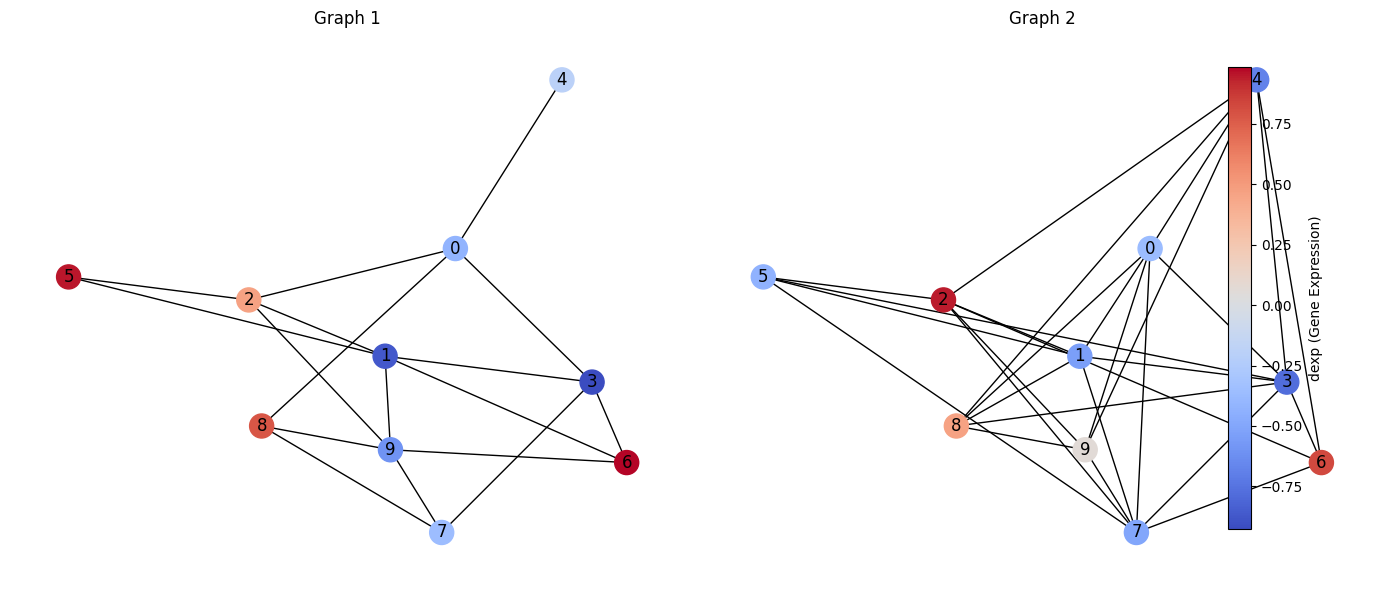

Cosine similarity between graphs: 0.9349


In [7]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.utils import from_networkx
from torch.nn import Sequential, Linear, ReLU
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import networkx as nx
import random


# 2 example NetworkX graphs

# number of nodes
num_nodes = 10
seed = 42 

# Generate two graphs w/ different edges
G1 = nx.erdos_renyi_graph(n=num_nodes, p=0.3, seed=seed)
G2 = nx.erdos_renyi_graph(n=num_nodes, p=0.6, seed=seed + 1)

# Random node signal values
for G in [G1, G2]:
    for node in G.nodes():
        G.nodes[node]['dexp'] = random.uniform(-1, 1)

# Same edge weights
for G in [G1, G2]:
    for u, v in G.edges():
        G[u][v]['weight'] = 1.0

# Visualise
def plot_graphs_with_colorbar(G1, G2, title1='Graph 1', title2='Graph 2'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    pos = nx.spring_layout(G1, seed=42)

    # Collect node colors
    dexp_vals_G1 = [G1.nodes[n]['dexp'] for n in G1.nodes()]
    dexp_vals_G2 = [G2.nodes[n]['dexp'] for n in G2.nodes()]
    all_dexp = dexp_vals_G1 + dexp_vals_G2

    norm = colors.Normalize(vmin=min(all_dexp), vmax=max(all_dexp))
    cmap = cm.get_cmap('coolwarm')

    # Draw graph(s)
    nx.draw(
        G1, pos, ax=axes[0], with_labels=True,
        node_color=dexp_vals_G1, cmap=cmap, vmin=norm.vmin, vmax=norm.vmax
    )
    axes[0].set_title(title1)

    
    nx.draw(
        G2, pos, ax=axes[1], with_labels=True,
        node_color=dexp_vals_G2, cmap=cmap, vmin=norm.vmin, vmax=norm.vmax
    )
    axes[1].set_title(title2)

    # Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.025, pad=0.02)
    cbar.set_label('dexp (Gene Expression)')

    plt.tight_layout()
    plt.show()


plot_graphs_with_colorbar(G1, G2)

# Convert graphs for PyTorch Geometric
def convert_graph(G):
    data = from_networkx(G, group_edge_attrs=['weight'])
    data.x = torch.tensor([[G.nodes[i]['dexp']] for i in G.nodes()], dtype=torch.float)
    data.batch = torch.zeros(data.num_nodes, dtype=torch.long) 
    return data

data1 = convert_graph(G1)
data2 = convert_graph(G2)

# GIN Model (paste link for reference)
class GIN(torch.nn.Module):
    def __init__(self, hidden_dim=64, output_dim=128):
        super().__init__()
        nn1 = Sequential(Linear(1, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        nn2 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.fc_out = Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)  # Graph-level embedding
        x = self.fc_out(x)
        return x

model = GIN()

# Graph Embeddings
model.eval()
with torch.no_grad():
    emb1 = model(data1.x, data1.edge_index, data1.batch)
    emb2 = model(data2.x, data2.edge_index, data2.batch)

# Embeddings similarity
similarity = cosine_similarity(emb1.numpy(), emb2.numpy())[0][0]

#print(f"Graph 1 embedding:\n{emb1}\n")
#print(f"Graph 2 embedding:\n{emb2}\n")
print(f"Cosine similarity between graphs: {similarity:.4f}")